# OGS EnKI

## Import libraries

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import solve_triangular

## Read Observation and OGS Parameters

In [38]:
data_ogs = pd.read_csv("ogs_data_total_u_at_timestep.csv", sep=";", decimal =",")

## Set up parameters

In [39]:
dim_output = len(data_ogs.total_u_at_timestep)  # number of elements / output parameters

# constant
gamma_water_const = 9.81e3  # unit weight of water [N/m3 or kPa/m]
time_step = 0.5       # element height Δz [m]

# changeable
n_ens = 100
n_iters = 10

# prior 
prior_mean = mean_stiff = np.linspace(15,18,dim_output) #lognormal 
var_stiff = np.random.uniform(0.4,0.5,dim_output) #0.56, 0.67
prior_cov = np.diag(var_stiff ) # prior covariance matrix, may vary as well

# should be reference fro mmesh_settings
layer_boundaries = [0, 10, 20, 30]  # in meters
layer_porosity = [0.8, 0.5, 0.2]     # porosity for each layer
layer_density =[1800, 2000, 2200]   # density for each layer
elements_depth = np.linspace(0, dim_output*time_step, dim_output, endpoint=False)  # depth at element center


# we create porosity vector for all elements
n_vec = np.zeros(dim_output)
for i in range(len(layer_porosity)):
    mask = (elements_depth >= layer_boundaries[i]) & (elements_depth < layer_boundaries[i+1])
    n_vec[mask] = layer_porosity[i]

# # We make the across layer porosity have a smooth transition (i.e. middle 2 has average of 2 porosity values)
# # find where the porosity value changes across layer
# diff_idx = np.where(np.diff(n_vec) != 0)[0]

# for idx in diff_idx:
#     avg = (n_vec[idx] + n_vec[idx+1]) / 2
#     n_vec[idx] = avg
#     n_vec[idx+1] = avg

log_distr = True  # use lognormal distribution

# observations
gamma_cov = 1e-50 #1e-13  # observation noise
y_observed = data_ogs.total_u_at_timestep.values[::-1]  # reverse to match bottom-up convention

# get original Es
theta_true = data_ogs.stiffness_modulus

In [40]:
theta_true.array

<NumpyExtensionArray>
[ 630110.5876509981, 1643894.8438638626,  2409290.123528714,
 3443042.4989742334,  4499451.675326879,  3991997.361723839,
 3796133.7580471584,  4980424.544847068,  4677681.897321432,
  5031989.853894975,  6075988.728478895,  6525685.061206149,
  7034590.912059216,  7845520.543159374,  9112054.130494902,
  10279117.40624941, 10013824.192543922, 10333656.762120696,
   9941145.21382257, 11324335.297910271,  15114756.93903787,
 14498651.131430782, 14959277.747712562,  19453640.34812351,
 22630040.822949234,  30005457.80686365,  31352631.14091704,
  30300826.12767516,  39231200.09081218,  35769756.61993762,
  30324440.29047436, 33721017.264917426,  26352908.57857859,
 23157816.454006225, 20855855.061028667,  15081082.94802142,
   14927880.9339317,  17683717.56268234, 19592834.841138296,
  45178027.67007743,  65198984.01652173,  66124673.63917784,
   54606115.6736649,   38040554.7507665,  31061917.85104552,
  33802377.02594145,  46229120.51181498,  52685855.28595862,
  

## Forward map G for uplift computation

If we model "inverse" stiffness the result fit perfectly to the the $G(E_{true})$

In [41]:
def G_forward_map(stiffness_vector, time_increment=0.5, porosity=None):
    n = np.max(stiffness_vector.shape)
    stiffness_vector = stiffness_vector[::-1]
    porosity = porosity[::-1]
    # lower-triangle matrix operator
    ltu_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(n):
            if i == j:
                ltu_matrix[i, j] = 0.5 * (1- porosity[i])
            elif i > j:
                ltu_matrix[i, j] = 1 * (1-porosity [i])

    uplift_vectors = 9.81e3 * time_increment**2 *  ltu_matrix @ (1/stiffness_vector)
    return uplift_vectors

## EnKI Class

In [42]:
class EnsembleKalmanInversion():
    
    def __init__(self, num_seed:int):
        """
        Creates EnKI instance

        params: 
            num_seed:int -  Sets seed for random numbers generator

        
        """
        self.enki_random_generator = np.random.default_rng(seed=num_seed)
        
    def fit(self, n_ensembles:int, n_iterations:int, y_true:np.array, time_step:float, prior_mean:np.array, prior_cov:np.array, dim_output:int, gamma_cov:float, log_distr:bool ):
        """
        Fits EnKI instance

        params: 
                    n_ensembles : int - number of ensembles used in the algorithm
                    dim_output : int - output dimension for the pestimated parameter vector
                    n_iterations :int - number of iterations of EnKI
                    time_step : float - grid stepsize 
                    log_distr : bool - Flag for using lognormal distribution(if set True)
                    prior_mean: np.array - prior mean vector for the estimated parameter
                    prior_cov : np.array - prior covariance matrix for the estimated parameter
                    gamma_cov : float - noise


        output: None
        
        """

        # initialize parameters
        self.n_ensembles = n_ensembles
        self.dim_output = dim_output
        self.n_iterations = n_iterations
        self.time_step = time_step
        self.final_mean_thetas = None
        self.final_var_thetas = None

        # check distribution type and initialize ensemble
        if log_distr==True:
            self.init_ensemble_thetas = np.exp(np.abs(self.enki_random_generator.multivariate_normal(mean=prior_mean, cov=prior_cov,size=self.n_ensembles)))#.reshape(-1, self.dim_output)
        else:
            self.init_ensemble_thetas = np.abs((self.enki_random_generator.multivariate_normal(mean=prior_mean, cov=prior_cov,size=self.n_ensembles)))#.reshape(-1, self.dim_output)

        # distort observed values
        self.gamma_covariance = gamma_cov * np.eye(self.dim_output)
        self.noise_distribution = ((self.enki_random_generator.multivariate_normal(mean=np.zeros(self.dim_output), cov=self.gamma_covariance)))
        self.Y_true = y_true + self.noise_distribution
        
        
    def run_inversion(self, forward_map:callable, **kwargs):
            self.track_thetas = [self.init_ensemble_thetas.mean(axis=0)]
            
            """
            Runs EnKI 

            params: 
                        forward_map : callable - function used as a forward map G, takes parameters values from ensemble and stepsize. Can be extended via keyword arguments and accepts any forward map which input signature starts with parameters and stepsize.
                        **kwargs - forward map keyword arguments, e.g for changing constants' values, optional
                        


            output: None
            
            """

            self.y_forward = np.zeros((self.n_ensembles , max(self.Y_true.shape )))
            self.ensemble_thetas = self.init_ensemble_thetas

            # perform  iterations 
            for i in range(0, self.n_iterations):
            
                # compute forward map for each ensemble member for a current iteration
                for j in range(0, self.n_ensembles):
                    
                    self.y_forward[j,:] = forward_map( self.ensemble_thetas[j,:], **kwargs)
            
                # parameter-forward map cross-covariance
                cov_theta_G =  (self.ensemble_thetas - np.mean(self.ensemble_thetas,axis=0)).T @ (self.y_forward - np.mean(self.y_forward, axis=0) ) / (self.n_ensembles-1)
                
                # forward map covariance
                cov_G_G =  (self.y_forward - np.mean(self.y_forward,axis=0)).T @ (self.y_forward - np.mean(self.y_forward,axis=0)) / (self.n_ensembles-1)

                # Residuals for forward map
                Z = (self.Y_true - self.y_forward).T
                # Kalman Gain 
                # K = cov_theta_G @ np.linalg.inv(self.gamma_covariance + cov_G_G) # using inv
                K = cov_theta_G @ np.linalg.solve( (self.gamma_covariance + cov_G_G),  Z) #using linalg.solve
            
                # Update parameters in ensembles
                # self.ensemble_thetas = self.ensemble_thetas + (K @ Z)#.T
                self.ensemble_thetas = self.ensemble_thetas + K.T
                self.track_thetas.append(self.ensemble_thetas.mean(axis=0))
            
            # record final parameter estimates
            self.final_mean_thetas = self.ensemble_thetas.mean(axis=0)
            self.final_var_thetas = self.ensemble_thetas.var(axis=0)
        
        
    def get_thetas_traces(self):
        """
        Returns estimated parameters for each iteration

        params: None


        output: list of np.arrays - list of Vector of estimated parameters
        
        """
        return self.track_thetas
        
    def get_final_thetas(self):
        """
        Returns estimated parameters

        params: None


        output: np.array - Vector of estimated parameters
        
        """
        return self.final_mean_thetas
        
    def get_final_var_thetas(self):
        """
        Returns variance of estimated parameters

        params: None


        output: np.array - Variance vector of estimated parameters
        
        """ 
        return self.final_var_thetas
    
    def get_uplift_with_noise(self):
        """
        Returns observation with noise

        params: None

        output: np.array 
        
        """ 
        return self.Y_true
        

### Create Forward Matrix Operator
This matrix should be passed into run_inversion() as a keyword argument of a forward map function.

## Intialize and fit EnKI instance

In [43]:
enki = EnsembleKalmanInversion(num_seed=23)

In [44]:
enki.fit(
         n_ensembles = n_ens,
         n_iterations=n_iters,
         y_true=y_observed, 
         #y_true = G_forward_map(theta_true,time_increment=time_step,porosity=n_vec),#using theta true from ogs instead
         time_step=time_step, 
         prior_mean=prior_mean, 
         prior_cov=prior_cov, 
         dim_output=dim_output,
         gamma_cov=gamma_cov,
         log_distr=log_distr
)

## Run inversion and infer parameter(stiffness) estimates

In [45]:
enki.run_inversion(
    forward_map=G_forward_map,
    porosity=n_vec             # element-wise porosity vector
)

In [46]:
mean_thetas = enki.get_final_thetas()
var_thetas = enki.get_final_var_thetas()
Y_true = enki.get_uplift_with_noise()

### Deterministic back estimation by analytical method

In [47]:
ltu_matrix = np.zeros((dim_output, dim_output))
for i in range(dim_output):
    for j in range(dim_output):
        if i == j:
            ltu_matrix[i, j] = 0.5 * (1- n_vec[::-1][i])
        elif i > j:
            ltu_matrix[i, j] = 1 * (1- n_vec[::-1][i])
b = Y_true / (gamma_water_const * time_step**2 )  # RHS
x = solve_triangular(ltu_matrix, b, lower=True)        # solve L @ x = b
Es_without_EnKI = 1 / x                                     # invert to get stiffness
Es_without_EnKI = Es_without_EnKI[::-1]  # reverse to match depth ordering

## Visualization

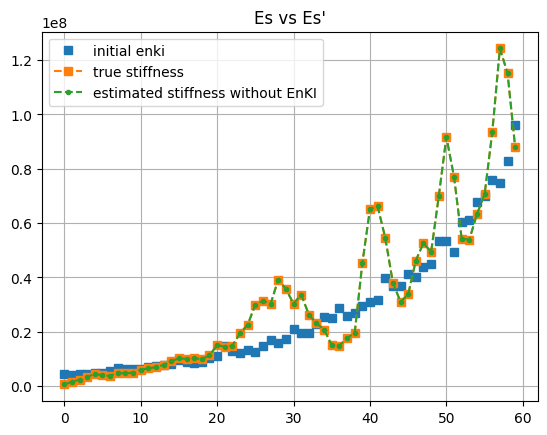

In [ ]:
%matplotlib inline
plt.close('all')
plt.plot(enki.init_ensemble_thetas.mean(0),"s",label="initial enki")
plt.plot(theta_true,'--s', label="true stiffness")
plt.plot(mean_thetas, '--*',label="estimated stiffness with EnKI")
plt.plot(Es_without_EnKI, '--.',label="estimated stiffness without EnKI")

plt.legend()
plt.title(rf"Es vs Es'")
plt.grid()

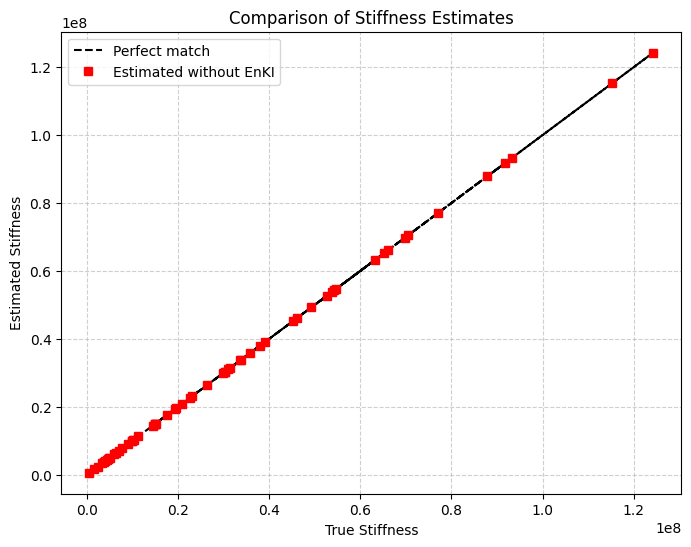

In [49]:
plt.figure(figsize=(8,6))

# With EnKI
# plt.errorbar(theta_true, mean_thetas,
#              fmt='o', color='blue',
#              label='Estimated with EnKI')

# Without EnKI
plt.errorbar(theta_true, Es_without_EnKI,
             fmt='s', color='red',
             label='Estimated without EnKI')

# Reference line (perfect match)
plt.plot(theta_true, theta_true, 'k--', label='Perfect match')

# Labels & legend
plt.xlabel("True Stiffness")
plt.ylabel("Estimated Stiffness")
plt.title("Comparison of Stiffness Estimates")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

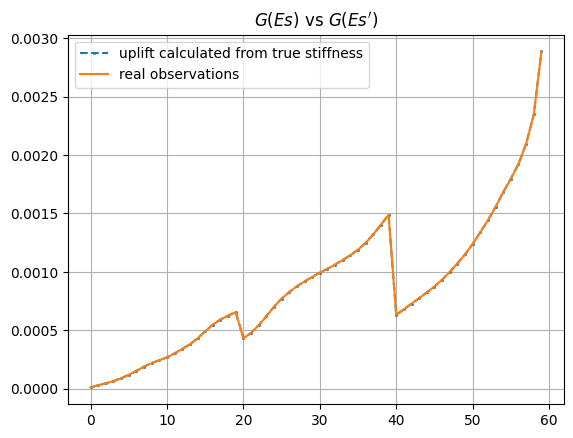

In [50]:
%matplotlib inline
plt.close('all')
plt.plot(G_forward_map(theta_true,time_increment=time_step,porosity=n_vec),'--s',markersize =1, label="uplift calculated from true stiffness")
#plt.plot(G_forward_map((mean_thetas),time_increment=time_step,porosity=n_vec),'--*', label="uplift calculated from estimated EnKI stiffness")
#plt.plot(G_forward_map((Es_without_EnKI),time_increment=time_step,porosity=n_vec),'--.', label="uplift calculated from estimated without EnKI stiffness")
#plt.plot(G_forward_map((enki.init_ensemble_thetas.mean(0)),time_increment=time_step,porosity=n_vec),label="initial enki")
plt.plot(y_observed, label="real observations")
plt.title(rf"$G(Es)$ vs $G(Es')$");
plt.legend()
plt.grid()

### Track Thetas

In [51]:
traces = enki.get_thetas_traces()

For interactive plots install following packages:

In [52]:
# import sys
# !{sys.executable} -m pip install ipympl
# !{sys.executable} -m pip install --upgrade ipympl

In [53]:
%matplotlib widget
from ipywidgets import interact
plt.close('all')

def thetas_interactive_plot(ix):

    plt.figure(figsize=(12, 9))
    plt.plot(enki.init_ensemble_thetas.mean(0),"s"         ,label="initial enki")
    plt.plot(theta_true,'--s', label="true stiffness");
    plt.plot( traces[ix],'--*',label=rf"  {ix}-th iteration  enki stiffness")
    plt.title(rf" $\theta^*$, iteration {ix} ")
   
    plt.legend();
    plt.grid(True)
    plt.show();


interact(thetas_interactive_plot, ix=(0,n_iters));

interactive(children=(IntSlider(value=5, description='ix', max=10), Output()), _dom_classes=('widget-interact'…

In [54]:
%matplotlib widget
from ipywidgets import interact
plt.close('all')

def GMap_interactive_plot(ix):

    plt.figure(figsize=(12, 9))

    
    plt.plot(G_forward_map(theta_true,time_increment=time_step,porosity=n_vec),'--s', label="from true stiffness")
    plt.plot(G_forward_map(traces[ix],time_increment=time_step,porosity=n_vec), '--*',label="enki");
    plt.plot(G_forward_map((enki.init_ensemble_thetas.mean(0)),time_increment=time_step,porosity=n_vec),"--",label="initial enki")
    plt.plot(y_observed, label="true observations")
    plt.title(rf"$G(\theta)$ vs $G(\theta^*)$, iteration {ix}")

    plt.legend()
    plt.grid(True)
    plt.show()


interact(GMap_interactive_plot, ix=(0,n_iters));

interactive(children=(IntSlider(value=5, description='ix', max=10), Output()), _dom_classes=('widget-interact'…

## Questions and Notes
- Is the forward map correct? 
- Optimal prior parameters? Mean and Covariance Matrix?
- Noise Г?